# Practice Lab - Tree Ensembles (Employee Attrition Dataset)

This notebook is a self-contained remix of the "Tree Ensemble" practice lab. It covers the exact same concepts, using a different, synthetically generated dataset so you can practice the workflow end-to-end.

In this notebook, you will:

 - Generate a realistic tabular dataset with a mix of numeric and categorical features
 - Use Pandas to perform one-hot encoding of the categorical features
 - Use scikit-learn to implement a Decision Tree and a Random Forest
 - Use XGBoost to implement a gradient-boosted tree ensemble with early stopping
 - Compare train vs. validation performance to build intuition about overfitting and underfitting

Let's import the libraries we will use.

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')  # a built-in matplotlib style, no external file needed

RANDOM_STATE = 55  # We will pass it everywhere we can to ensure reproducibility

# 1. Introduction

#### Dataset
- This dataset is **synthetically generated** inside this notebook (see Section 1.1 below), so the notebook is fully self-contained and does not depend on downloading any external file.
- It is modeled after the well-known "Employee Attrition" style of HR datasets (e.g. the IBM HR Analytics dataset on Kaggle), but the values here are simulated with numpy so you can regenerate, resize, or tweak it freely.

#### Context
- Employee attrition (employees leaving a company) is a costly problem for organizations: replacing an employee typically costs a significant fraction of their annual salary once recruiting, onboarding, and lost productivity are accounted for.
- Being able to flag employees who are at high risk of leaving lets HR and managers intervene early (adjust workload, discuss compensation, etc.).
- This dataset contains 14 features that can be used to predict whether an employee will leave the company.
- Let's train a machine learning model to help flag at-risk employees.

#### Attribute Information
- Age: age of the employee \[years\]
- MonthlyIncome: monthly salary \[USD\]
- DistanceFromHome: distance between home and office \[km\]
- YearsAtCompany: tenure at the current company \[years\]
- TotalWorkingYears: total years of professional experience \[years\]
- NumCompaniesWorked: number of companies worked at previously
- PercentSalaryHike: percentage salary increase at the last review \[%\]
- JobSatisfaction: self-reported job satisfaction \[1: Low, 2: Medium, 3: High, 4: Very High\]
- WorkLifeBalance: self-reported work-life balance \[1: Bad, 2: Good, 3: Better, 4: Best\]
- OverTime: whether the employee regularly works overtime \[Yes / No\]
- Department: department the employee works in \[Sales, Research_Development, Human_Resources\]
- EducationField: field of the employee's degree \[Life_Sciences, Medical, Marketing, Technical_Degree, Other\]
- MaritalStatus: marital status \[Single, Married, Divorced\]
- BusinessTravel: how often the employee travels for work \[Non-Travel, Travel_Rarely, Travel_Frequently\]
- Attrition: output class \[1: employee left, 0: employee stayed\]

## 1.1 Generating the dataset

Instead of downloading a CSV, we'll generate the dataset with `numpy`. We define a "risk score" for each simulated employee that increases with known real-world attrition drivers (overtime, frequent travel, being single, low satisfaction, low work-life balance, long commute, having worked at many previous companies) and decreases with others (tenure, income, age). We then pass that score through a logistic function to get a probability of leaving, and sample the actual outcome from that probability.

This mirrors how the original lab's heart disease dataset relates features to a binary medical outcome, except here the "ground truth" relationship is one we define ourselves, and a fixed `RANDOM_STATE` makes it fully reproducible.

In [2]:
n_samples = 1500
rng = np.random.default_rng(RANDOM_STATE)

# Numeric features
age = rng.integers(18, 60, n_samples)
monthly_income = rng.normal(6000, 2000, n_samples).clip(1500, 20000).round(2)
distance_from_home = rng.integers(1, 30, n_samples)
years_at_company = rng.integers(0, 25, n_samples)
total_working_years = (years_at_company + rng.integers(0, 10, n_samples)).clip(0, 40)
num_companies_worked = rng.integers(0, 8, n_samples)
percent_salary_hike = rng.integers(10, 25, n_samples)
job_satisfaction = rng.integers(1, 5, n_samples)
work_life_balance = rng.integers(1, 5, n_samples)

# Categorical features
overtime = rng.choice(['Yes', 'No'], size=n_samples, p=[0.3, 0.7])
department = rng.choice(['Sales', 'Research_Development', 'Human_Resources'],
                         size=n_samples, p=[0.35, 0.55, 0.10])
education_field = rng.choice(['Life_Sciences', 'Medical', 'Marketing', 'Technical_Degree', 'Other'],
                              size=n_samples, p=[0.35, 0.25, 0.15, 0.15, 0.10])
marital_status = rng.choice(['Single', 'Married', 'Divorced'], size=n_samples, p=[0.35, 0.5, 0.15])
business_travel = rng.choice(['Non-Travel', 'Travel_Rarely', 'Travel_Frequently'],
                              size=n_samples, p=[0.1, 0.6, 0.3])

# Latent "risk score" -> probability of attrition -> sampled outcome
score = (
    -2.6
    + 1.3 * (overtime == 'Yes')
    + 0.55 * (business_travel == 'Travel_Frequently')
    - 0.5 * (business_travel == 'Non-Travel')
    + 0.75 * (marital_status == 'Single')
    - 0.35 * (job_satisfaction - 2.5)
    - 0.35 * (work_life_balance - 2.5)
    + 0.045 * (distance_from_home - 15)
    - 0.06 * (years_at_company - 5)
    + 0.18 * (num_companies_worked - 3)
    - 0.00012 * (monthly_income - 6000)
    - 0.02 * (age - 35)
    + rng.normal(0, 1.35, n_samples)  # noise, so the outcome isn't perfectly deterministic
)
probability_of_leaving = 1 / (1 + np.exp(-score))
attrition = (rng.random(n_samples) < probability_of_leaving).astype(int)

df = pd.DataFrame({
    'Age': age,
    'MonthlyIncome': monthly_income,
    'DistanceFromHome': distance_from_home,
    'YearsAtCompany': years_at_company,
    'TotalWorkingYears': total_working_years,
    'NumCompaniesWorked': num_companies_worked,
    'PercentSalaryHike': percent_salary_hike,
    'JobSatisfaction': job_satisfaction,
    'WorkLifeBalance': work_life_balance,
    'OverTime': overtime,
    'Department': department,
    'EducationField': education_field,
    'MaritalStatus': marital_status,
    'BusinessTravel': business_travel,
    'Attrition': attrition,
})

print(f'Dataset shape: {df.shape}')
print(f'Attrition rate: {df["Attrition"].mean():.4f}')

Dataset shape: (1500, 15)
Attrition rate: 0.1827


In [3]:
df.head()

,Age,MonthlyIncome,DistanceFromHome,YearsAtCompany,TotalWorkingYears,NumCompaniesWorked,PercentSalaryHike,JobSatisfaction,WorkLifeBalance,OverTime,Department,EducationField,MaritalStatus,BusinessTravel,Attrition
0,58,2758.66,14,2,3,5,13,2,3,Yes,Sales,Life_Sciences,Single,Travel_Rarely,1
1,52,4812.85,1,22,26,6,22,1,3,No,Research_Development,Life_Sciences,Single,Travel_Rarely,0
2,48,6071.48,5,9,17,6,22,4,2,No,Research_Development,Life_Sciences,Married,Travel_Frequently,0
3,54,2627.31,16,7,12,0,16,4,4,Yes,Research_Development,Medical,Divorced,Travel_Rarely,0
4,27,2864.82,7,1,9,3,16,2,3,Yes,Research_Development,Life_Sciences,Single,Travel_Rarely,0


We must perform some data engineering before working with the models. There are 5 categorical features, so we will use Pandas to one-hot encode them, exactly as in the original lab.

## 2. One-hot encoding using Pandas

First we will list the categorical variables. Just like in the original lab, one-hot encoding a variable that only has 2 distinct values (like `OverTime`) still works fine here, so we don't need to filter those out separately.

In [4]:
cat_variables = [
    'OverTime',
    'Department',
    'EducationField',
    'MaritalStatus',
    'BusinessTravel',
]

As a reminder, one-hot encoding aims to transform a categorical variable with `n` outputs into `n` binary variables.

Pandas has a built-in method to one-hot encode variables: `pd.get_dummies`. We will use a few of its arguments:

 - data: DataFrame to be used
 - prefix: A list with prefixes, so we know which value we are dealing with
 - columns: the list of columns that will be one-hot encoded. `prefix` and `columns` must have the same length.

For more information, you can always type `help(pd.get_dummies)` to read the function's full documentation.

In [5]:
# This will replace the columns with the one-hot encoded ones and keep the columns outside 'columns' argument as it is.
df = pd.get_dummies(data=df,
                     prefix=cat_variables,
                     columns=cat_variables)

In [6]:
df.head()

,Age,MonthlyIncome,DistanceFromHome,YearsAtCompany,TotalWorkingYears,NumCompaniesWorked,PercentSalaryHike,JobSatisfaction,WorkLifeBalance,Attrition,...,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical_Degree,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely
0,58,2758.66,14,2,3,5,13,2,3,1,...,False,False,False,False,False,False,True,False,False,True
1,52,4812.85,1,22,26,6,22,1,3,0,...,False,False,False,False,False,False,True,False,False,True
2,48,6071.48,5,9,17,6,22,4,2,0,...,False,False,False,False,False,True,False,False,True,False
3,54,2627.31,16,7,12,0,16,4,4,0,...,False,True,False,False,True,False,False,False,False,True
4,27,2864.82,7,1,9,3,16,2,3,0,...,False,False,False,False,False,False,True,False,False,True


Let's choose the variables that will be the input features of the model.
- The target is `Attrition`.
- All other variables are features that can potentially be used to predict the target, `Attrition`.

In [7]:
features = [x for x in df.columns if x not in 'Attrition']  ## Removing our target variable

We started with 14 features. Let's see how many feature variables we have after one-hot encoding.

In [8]:
print(len(features))

25


# 3. Splitting the Dataset

In this section, we will split our dataset into train and validation datasets, using `train_test_split` from Scikit-learn, just like the original lab.

In [9]:
help(train_test_split)

Help on function train_test_split in module sklearn.model_selection._split:

train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
    Split arrays or matrices into random train and test subsets.

    Quick utility that wraps input validation,
    ``next(ShuffleSplit().split(X, y))``, and application to input data
    into a single call for splitting (and optionally subsampling) data into a
    one-liner.

    Read more in the :ref:`User Guide <cross_validation>`.

    Parameters
    ----------
    *arrays : sequence of indexables with same length / shape[0]
        Allowed inputs are lists, numpy arrays, scipy-sparse
        matrices or pandas dataframes.

    test_size : float or int, default=None
        If float, should be between 0.0 and 1.0 and represent the proportion
        of the dataset to include in the test split. If int, represents the
        absolute number of test samples. If None, the value is set to the
        com

In [10]:
X_train, X_val, y_train, y_val = train_test_split(df[features], df['Attrition'], train_size=0.8, random_state=RANDOM_STATE)

# We keep shuffle = True (the default) since our dataset has no time dependency.

In [11]:
print(f'train samples: {len(X_train)}')
print(f'validation samples: {len(X_val)}')
print(f'target proportion: {sum(y_train)/len(y_train):.4f}')

train samples: 1200
validation samples: 300
target proportion: 0.1942


# 4. Building the Models

## 4.1 Decision Tree

Let's work with the Decision Tree using the [Scikit-learn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

There are several hyperparameters in the Decision Tree object from Scikit-learn. We will use only some of them, and we will not perform full feature selection or exhaustive hyperparameter tuning in this lab (but you are encouraged to do so and compare the results 😄).

The hyperparameters we will investigate here are:

 - min_samples_split: The minimum number of samples required to split an internal node.
   - Choosing a higher min_samples_split can reduce the number of splits and may help to reduce overfitting.
 - max_depth: The maximum depth of the tree.
   - Choosing a lower max_depth can reduce the number of splits and may help to reduce overfitting.

In [12]:
min_samples_split_list = [2, 10, 30, 50, 100, 200, 300, 700]  ## If the number is an integer, it is the actual quantity of samples,
                                                                 ## if it is a float, it is the percentage of the dataset
max_depth_list = [1, 2, 3, 4, 8, 16, 32, 64, None]  # None means there is no depth limit.

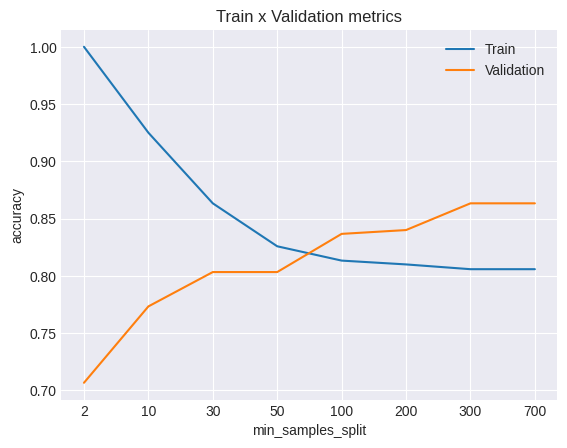

In [13]:
accuracy_list_train = []
accuracy_list_val = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(min_samples_split=min_samples_split,
                                    random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train)  ## The predicted values for the train dataset
    predictions_val = model.predict(X_val)      ## The predicted values for the validation dataset
    accuracy_train = accuracy_score(predictions_train, y_train)
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(min_samples_split_list)), labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])
plt.show()

Note how increasing `min_samples_split` reduces overfitting.
- As `min_samples_split` grows, training accuracy comes down towards validation accuracy, showing a reduction in overfitting - even where it does not improve validation accuracy itself.

Let's do the same experiment with `max_depth`.

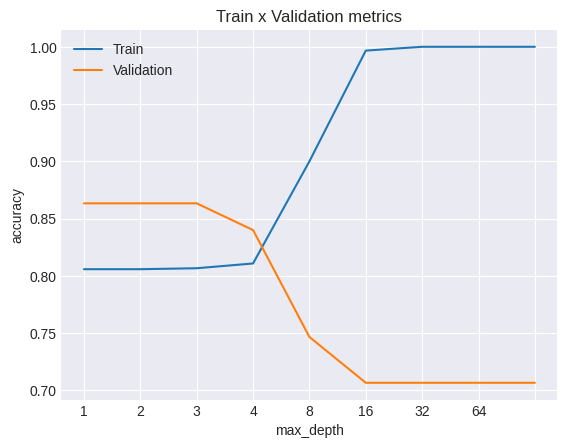

In [14]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = DecisionTreeClassifier(max_depth=max_depth,
                                    random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train)  ## The predicted values for the train dataset
    predictions_val = model.predict(X_val)      ## The predicted values for the validation dataset
    accuracy_train = accuracy_score(predictions_train, y_train)
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(max_depth_list)), labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])
plt.show()

We can see that, in general, reducing `max_depth` helps reduce overfitting here.
- Validation accuracy peaks around a shallow tree (roughly `max_depth = 3`), while training accuracy keeps climbing to 1.0 as depth grows unrestricted - the classic overfitting signature.
- When `max_depth` is very small (1-2), both training and validation accuracy are limited, because the tree can't make enough splits to capture the pattern (underfitting).
- When `max_depth` is large (>= 8), training accuracy keeps rising while validation accuracy drops, showing the model is memorizing the training set instead of generalizing.

So we can choose reasonable values for these two hyperparameters to be:
- `max_depth = 3`
- `min_samples_split = 50`

Feel free to re-run the sweeps above and confirm this for yourself - with a different `RANDOM_STATE` or dataset size the exact optimum may shift slightly, which is expected.

In [15]:
decision_tree_model = DecisionTreeClassifier(min_samples_split=50,
                                              max_depth=3,
                                              random_state=RANDOM_STATE).fit(X_train, y_train)

In [16]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_train), y_train):.4f}")
print(f"Metrics validation:\n\tAccuracy score: {accuracy_score(decision_tree_model.predict(X_val), y_val):.4f}")

Metrics train:
	Accuracy score: 0.8058
Metrics validation:
	Accuracy score: 0.8633


Little to no sign of overfitting, even though the metrics themselves are modest - this is a noisy, simulated target after all.

## 4.2 Random Forest

Now let's try the Random Forest algorithm, again using the Scikit-learn implementation.
- All of the hyperparameters found in the decision tree model also exist here, since a random forest is an ensemble of many Decision Trees.
- One additional hyperparameter for Random Forest is `n_estimators`, the number of Decision Trees that make up the forest.

Remember that for a Random Forest, we randomly choose a subset of the features AND a subset of the training examples to train each individual tree.
- If $n$ is the number of features, we randomly select roughly $\sqrt{n}$ of them to train each individual tree.
- You can modify this behavior with the `max_features` parameter.

You can also speed up training with the `n_jobs` parameter.
- Since each tree is fit independently, more than one can be trained in parallel.
- Setting `n_jobs` higher will use more CPU cores. Values very close to your CPU's maximum may slow down or even freeze your machine.
- Changing `n_jobs` does not change the final result, only the training time.

We will run the same style of sweep again, adding `n_estimators`, where we will try 10, 50, 100, and 500. The scikit-learn default is 100.

In [17]:
min_samples_split_list = [2, 10, 30, 50, 100, 200, 300, 700]
max_depth_list = [2, 4, 8, 16, 32, 64, None]
n_estimators_list = [10, 50, 100, 500]

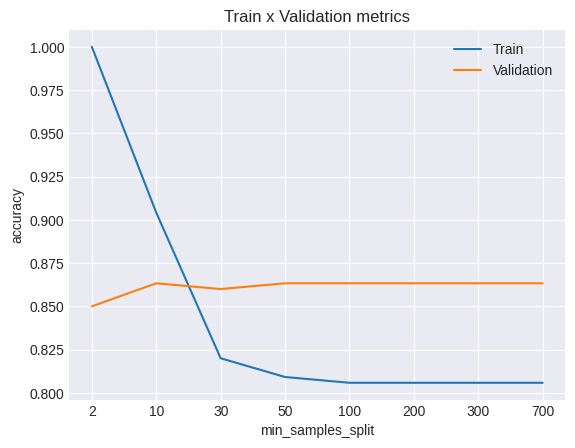

In [18]:
accuracy_list_train = []
accuracy_list_val = []
for min_samples_split in min_samples_split_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(min_samples_split=min_samples_split,
                                    random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train)  ## The predicted values for the train dataset
    predictions_val = model.predict(X_val)      ## The predicted values for the validation dataset
    accuracy_train = accuracy_score(predictions_train, y_train)
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('min_samples_split')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(min_samples_split_list)), labels=min_samples_split_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])
plt.show()

Notice that even where validation accuracy stays fairly flat across values of `min_samples_split`, higher values shrink the gap between training and validation accuracy, showing less overfitting - the same pattern we saw for the single Decision Tree, just less extreme because the forest already averages away some of the noise.

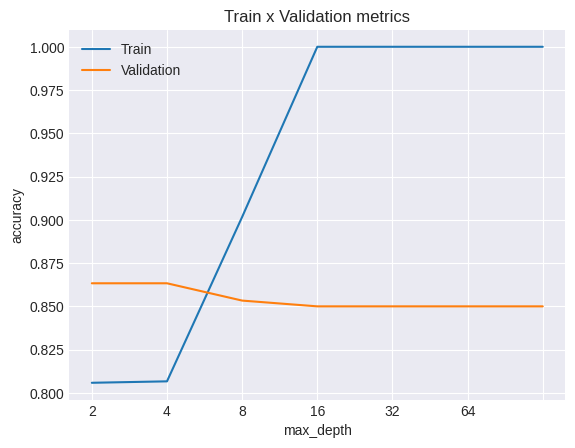

In [19]:
accuracy_list_train = []
accuracy_list_val = []
for max_depth in max_depth_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(max_depth=max_depth,
                                    random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train)  ## The predicted values for the train dataset
    predictions_val = model.predict(X_val)      ## The predicted values for the validation dataset
    accuracy_train = accuracy_score(predictions_train, y_train)
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(max_depth_list)), labels=max_depth_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])
plt.show()

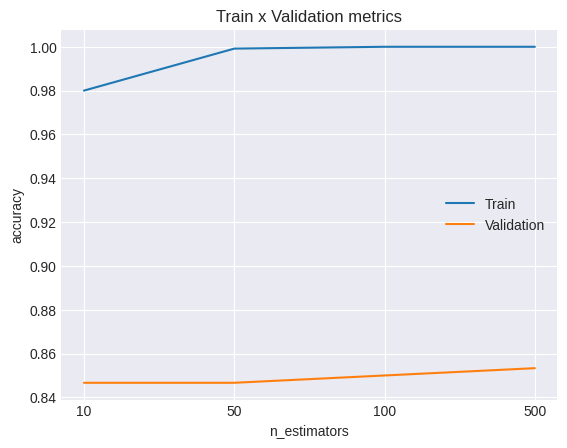

In [20]:
accuracy_list_train = []
accuracy_list_val = []
for n_estimators in n_estimators_list:
    # You can fit the model at the same time you define it, because the fit function returns the fitted estimator.
    model = RandomForestClassifier(n_estimators=n_estimators,
                                    random_state=RANDOM_STATE).fit(X_train, y_train)
    predictions_train = model.predict(X_train)  ## The predicted values for the train dataset
    predictions_val = model.predict(X_val)      ## The predicted values for the validation dataset
    accuracy_train = accuracy_score(predictions_train, y_train)
    accuracy_val = accuracy_score(predictions_val, y_val)
    accuracy_list_train.append(accuracy_train)
    accuracy_list_val.append(accuracy_val)

plt.title('Train x Validation metrics')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.xticks(ticks=range(len(n_estimators_list)), labels=n_estimators_list)
plt.plot(accuracy_list_train)
plt.plot(accuracy_list_val)
plt.legend(['Train', 'Validation'])
plt.show()

Let's then fit a random forest with the following parameters:

 - max_depth: 8
 - min_samples_split: 50
 - n_estimators: 100

In [21]:
random_forest_model = RandomForestClassifier(n_estimators=100,
                                              max_depth=8,
                                              min_samples_split=50,
                                              random_state=RANDOM_STATE).fit(X_train, y_train)

In [22]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_train), y_train):.4f}\nMetrics validation:\n\tAccuracy score: {accuracy_score(random_forest_model.predict(X_val), y_val):.4f}")

Metrics train:
	Accuracy score: 0.8092
Metrics validation:
	Accuracy score: 0.8633


Note that we are searching for the best value of one hyperparameter at a time while leaving the others at their default values.
- Ideally, we would want to check every combination of values for every hyperparameter we are tuning.
- If we have 3 hyperparameters and each has 4 candidate values, there are a total of 4 x 4 x 4 = 64 combinations to try.
- When we only vary one hyperparameter at a time while leaving the rest at their default, we only try 4 + 4 + 4 = 12 combinations.
- To try every combination, scikit-learn provides `GridSearchCV`, which also has a `refit` parameter that automatically refits a model on the best combination found, so you don't need to do it manually. See its [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) for more.

## 4.3 XGBoost

Next is the gradient boosting model, XGBoost. Boosting methods also train several trees, but instead of the trees being uncorrelated (as in bagging/Random Forest), the trees are fit one after another, each one trying to correct the errors of the previous ones.

The model shares the same core hyperparameters as a decision tree, plus a `learning_rate`.
- The learning rate controls the size of each step XGBoost takes internally to minimize its loss, similar to the learning rate in gradient descent.

One useful feature of XGBoost is that during fitting, it can take an evaluation dataset of the form `(X_val, y_val)`.
- On each boosting round, it measures the cost (or evaluation metric) on the evaluation set.
- Once that metric stops improving for a number of rounds (`early_stopping_rounds`), training stops automatically.
- More rounds means more estimators (more trees), and more estimators can lead to overfitting.
- By stopping once the validation metric stalls, we cap the number of trees and reduce overfitting.

First, let's carve out a subset of our training set to use purely for early stopping (we should never use the validation/test set for this).

In [23]:
n = int(len(X_train) * 0.8)  ## Let's use 80% to fit and 20% as an internal evaluation split

In [24]:
X_train_fit, X_train_eval, y_train_fit, y_train_eval = X_train[:n], X_train[n:], y_train[:n], y_train[n:]

We can set a large number of estimators up front, because training will stop early once the loss stops improving.

Note some of the parameters used below:
- `early_stopping_rounds`: passed to the `XGBClassifier` constructor in recent XGBoost versions. It stops training if the evaluation metric hasn't improved for that many consecutive rounds.
  - The model keeps track of the round with the best (lowest) evaluation metric. Say round 13 has the best log loss so far.
  - Each following round's metric is compared against that best value. If 10 rounds go by (`early_stopping_rounds = 10`) with none beating it, training stops.
  - The final returned model reflects its state at the round training stopped, not necessarily the single best round - though XGBoost also exposes `.best_iteration` so you know exactly where the best round was.
- `eval_set = [(X_train_eval, y_train_eval)]`: a list of one or more `(X, y)` tuples XGBoost uses to track the evaluation metric on each round.

In [25]:
xgb_model = XGBClassifier(n_estimators=500,
                           learning_rate=0.1,
                           early_stopping_rounds=10,
                           eval_metric='logloss',
                           verbosity=1,
                           random_state=RANDOM_STATE)
xgb_model.fit(X_train_fit, y_train_fit, eval_set=[(X_train_eval, y_train_eval)])

[0]	validation_0-logloss:0.55554


[1]	validation_0-logloss:0.54926


[2]	validation_0-logloss:0.54760


[3]	validation_0-logloss:0.54205


[4]	validation_0-logloss:0.53548


...

[25]	validation_0-logloss:0.52466


[26]	validation_0-logloss:0.52600


[27]	validation_0-logloss:0.53010


[28]	validation_0-logloss:0.52944


,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets impo

Even though we allowed up to 500 estimators, the algorithm stopped much earlier once the validation log loss stopped improving.

To see exactly where, look at the validation log loss printed above, or check the model's `.best_iteration` attribute directly:

In [26]:
xgb_model.best_iteration

18

- For 10 rounds of training after the best round, the log loss stayed higher than the best value.
- Since `early_stopping_rounds` was set to 10, training stopped once that 10-round window passed without improvement.
- Try different values of `early_stopping_rounds` (e.g. 5 or 20) and re-run the cell above to see how the stopping point changes.

In [27]:
print(f"Metrics train:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_train), y_train):.4f}\nMetrics validation:\n\tAccuracy score: {accuracy_score(xgb_model.predict(X_val), y_val):.4f}")

Metrics train:
	Accuracy score: 0.8617
Metrics validation:
	Accuracy score: 0.8600


In this example, the Decision Tree, Random Forest, and XGBoost all land in a similar accuracy range on the validation set, which makes sense given how much noise we deliberately injected into the simulated target.

## 5. Conclusion & Ideas to Explore Further

Congratulations, you've practiced the same Decision Tree / Random Forest / XGBoost workflow from the original lab on a brand-new, self-generated dataset!

Some ideas if you want to keep practicing:
- Try `GridSearchCV` (mentioned above) to jointly tune `max_depth`, `min_samples_split`, and `n_estimators` instead of one at a time.
- Increase or decrease the noise term in the `score` formula in Section 1.1 and re-run everything - watch how the achievable accuracy and the overfitting curves shift.
- Inspect `random_forest_model.feature_importances_` (or the XGBoost equivalent) to see which features the models found most useful for predicting attrition.
- Change `n_samples` to generate a bigger or smaller dataset and see how that affects overfitting at high `max_depth` values.